In [78]:
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sb



In [79]:
#Read in the data and check it's sensible
df = pd.read_csv('dogs.csv',sep=', ',na_values=['?'], engine="python")
df.head(5)

,Day,Month,Time_Start,Time_End,N_Dogs,Weather,Temperature,Route
0,Monday,January,14:37,15:20,19,NaN,NaN,NaN
1,Tuesday,January,13:58,15:00,26,NaN,NaN,NaN
2,Wednesday,January,14:05,15:00,16,NaN,NaN,NaN
3,Thursday,January,14:04,14:54,6,NaN,NaN,NaN
4,Thursday,January,15:52,16:12,10,NaN,NaN,NaN


## Calculate some useful properties

In [80]:
#Read start and end times into datetime format 
starts = [dt.strptime(i,"%H:%M") for i in df["Time_Start"]]
ends = [dt.strptime(i,"%H:%M") for i in df["Time_End"]]
#Find the total walk length and the median walk time for each walk
durations = [ends[i] - starts[i] for i in range(len(ends))]
median_walk_times = [starts[i] + durations[i]/2.0 for i in range(len(starts))]
#Convert durations into minutes and median time into HH:MM string
durations_str = [abs(i.total_seconds())/60.0 for i in durations]
median_walk_times_str = [dt.strftime(i,"%H:%M") for i in median_walk_times]
#Also want median walk time as fractional hours from midnight
median_walk_time_fractional_hours = [(i - dt.strptime("00:00","%H:%M")).total_seconds()/3600.0 for i in median_walk_times]


df["Duration_Min"] = durations_str
df["Avg_Time"] = median_walk_times_str
df["Avg_Time_Hour"] = median_walk_time_fractional_hours
df["Dogs_Per_Min"] = df["N_Dogs"]/df["Duration_Min"]

#Turn bools/strings into data we can do some tests with
df["Walk_Type"] = df["Avg_Time_Hour"]<12
df["Walk_Type"] = df['Walk_Type'].replace({True: "Morning", False: "Afternoon"})
df["Temperature_int"] = df['Temperature'].replace({'Cold': 1, 'Mild': 2, 'Warm': 3, 'Hot': 4})
df["Day_int"] = df['Day'].replace({'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7})

df.tail(5)

,Day,Month,Time_Start,Time_End,N_Dogs,Weather,Temperature,Route,Duration_Min,Avg_Time,Avg_Time_Hour,Dogs_Per_Min,Walk_Type,Temperature_int,Day_int
132,Wednesday,April,15:29,16:15,22,Sunny,Warm,Neighbourhoods,46.0,15:52,15.866667,0.478261,Afternoon,3.0,3
133,Thursday,April,10:14,10:43,5,Sunny,Mild,Morning,29.0,10:28,10.475000,0.172414,Morning,2.0,4
134,Thursday,April,14:05,14:44,8,Sunny,Warm,Short,39.0,14:24,14.408333,0.205128,Afternoon,3.0,4
135,Friday,April,10:02,10:30,6,Sunny,Warm,Morning,28.0,10:16,10.266667,0.214286,Morning,3.0,5
136,Friday,April,15:05,15:48,8,Sunny,Warm,Short,43.0,15:26,15.441667,0.186047,Afternoon,3.0,5


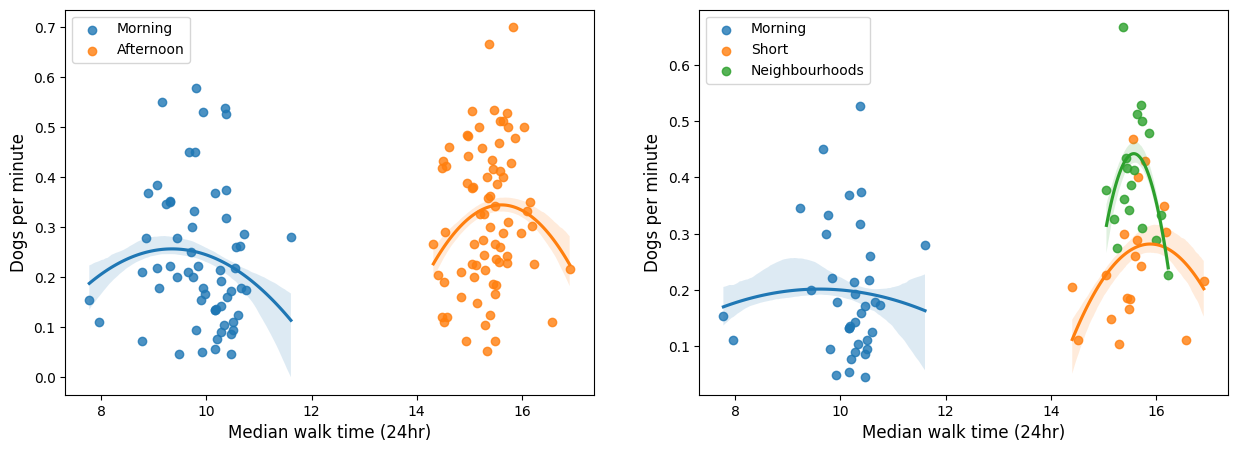

In [81]:
#Plot DPM for median walk times split by morning and afternoon (assuming suitably distinct datasets) and by chosen afternoon route
fig, axs = plt.subplots(1,2,figsize=(15,5))

mornings_bytime = sb.regplot(df[df["Walk_Type"]=="Morning"], order=2, x="Avg_Time_Hour", y='Dogs_Per_Min', ci=50, ax=axs[0], color=sb.color_palette()[0], label="Morning")
afternoons_bytime = sb.regplot(df[df["Walk_Type"]=="Afternoon"], order=2, x="Avg_Time_Hour", y='Dogs_Per_Min', ci=50, ax=axs[0], color=sb.color_palette()[1], label="Afternoon")

axs[0].set_xlabel('Median walk time (24hr)', color='black', fontsize=12)
axs[0].set_ylabel('Dogs per minute', color='black', fontsize=12)
axs[0].legend()

#Split the afternoon dataset into short and neighbourhood routes
morning_bytime = sb.regplot(df[df["Route"]=="Morning"], order=2, x="Avg_Time_Hour", y='Dogs_Per_Min', ci=50, ax=axs[1], color=sb.color_palette()[0], label="Morning")
short_bytime = sb.regplot(df[df["Route"]=="Short"], order=2, x="Avg_Time_Hour", y='Dogs_Per_Min', ci=50, ax=axs[1], color=sb.color_palette()[1], label="Short")
neighbourhood_bytime = sb.regplot(df[df["Route"]=="Neighbourhoods"], order=2, x="Avg_Time_Hour", y='Dogs_Per_Min', ci=50, ax=axs[1], color=sb.color_palette()[2], label="Neighbourhoods")

axs[1].set_xlabel('Median walk time (24hr)', color='black', fontsize=12)
axs[1].set_ylabel('Dogs per minute', color='black', fontsize=12)
axs[1].legend()


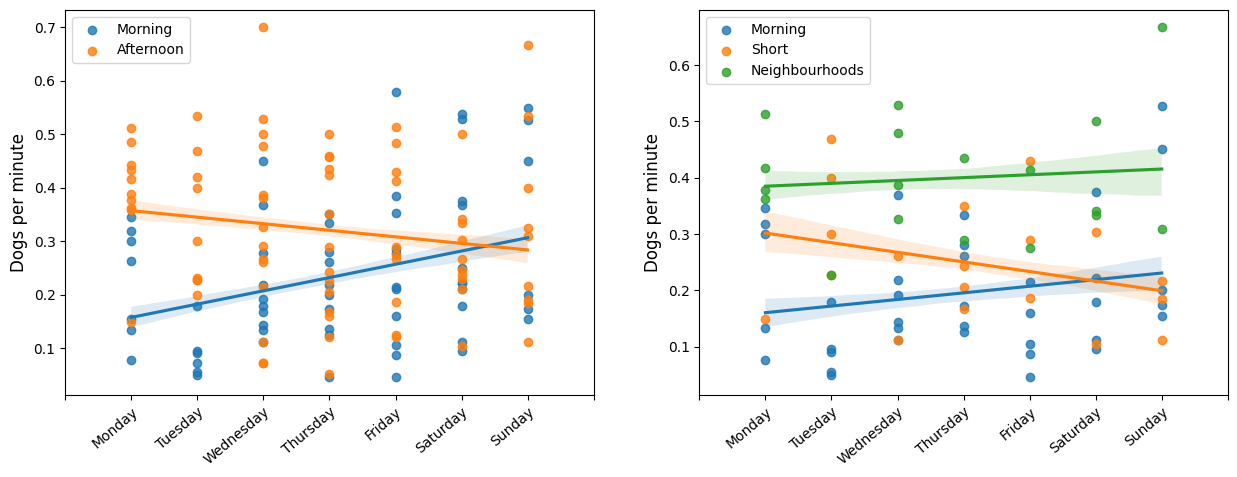

In [82]:
#Plot DPM for median walk times averaged across each day, split by morning and afternoon (assuming suitably distinct datasets) and by chosen afternoon route
fig, axs = plt.subplots(1,2,figsize=(15,5))

mornings_byday = sb.regplot(df[df["Walk_Type"]=="Morning"], order=1, x="Day_int", y='Dogs_Per_Min', ci=50, ax=axs[0], color=sb.color_palette()[0], label="Morning")
afternoons_byday = sb.regplot(df[df["Walk_Type"]=="Afternoon"], order=1, x="Day_int", y='Dogs_Per_Min', ci=50, ax=axs[0], color=sb.color_palette()[1], label="Afternoon")

axs[0].set_xlabel('')
axs[0].xaxis.set_ticks(range(0,9))
axs[0].set_xticklabels(["","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday",""],rotation=40, ha="right",rotation_mode='anchor')

axs[0].set_ylabel('Dogs per minute', color='black', fontsize=12)
axs[0].legend()

morning_byday = sb.regplot(df[df["Route"]=="Morning"], order=1, x="Day_int", y='Dogs_Per_Min', ci=50, ax=axs[1], color=sb.color_palette()[0], label="Morning")
short_byday = sb.regplot(df[df["Route"]=="Short"], order=1, x="Day_int", y='Dogs_Per_Min', ci=50, ax=axs[1], color=sb.color_palette()[1], label="Short")
neighbourhood_byday = sb.regplot(df[df["Route"]=="Neighbourhoods"], order=1, x="Day_int", y='Dogs_Per_Min', ci=50, ax=axs[1], color=sb.color_palette()[2], label="Neighbourhoods")

axs[1].set_xlabel('')
axs[1].xaxis.set_ticks(range(0,9))
axs[1].set_xticklabels(["","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday",""],rotation=40, ha="right",rotation_mode='anchor')

axs[1].set_ylabel('Dogs per minute', color='black', fontsize=12)
axs[1].legend()

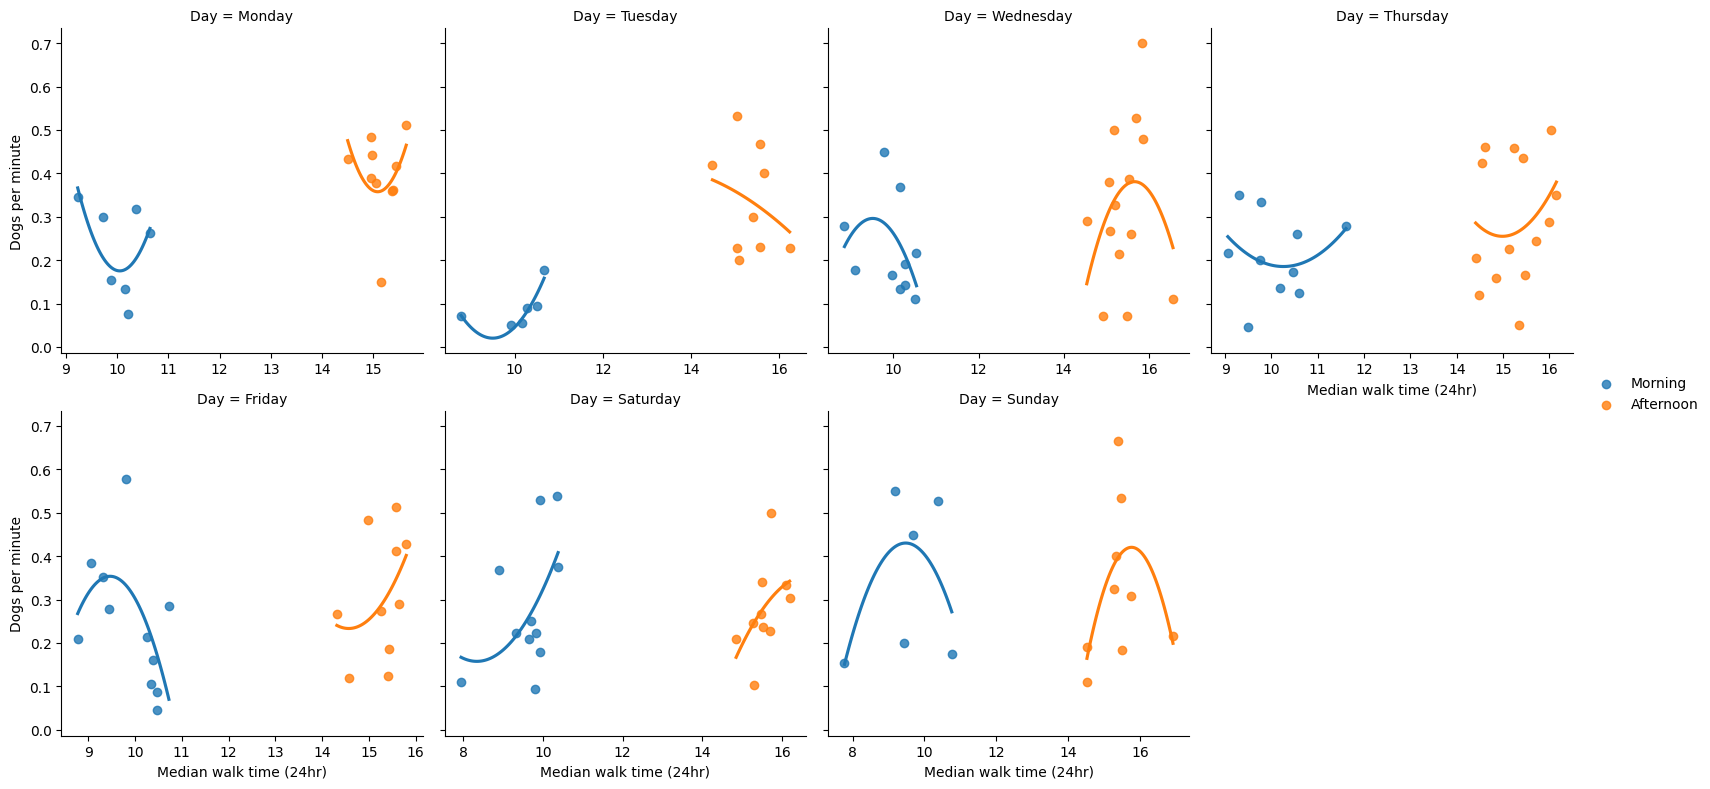

In [83]:
#Combine to see the DPM across timeslots for each day (don't split by route due to lack of data)
grid_by_month = sb.FacetGrid(df,col="Day",col_wrap=4,hue="Walk_Type",hue_order=["Morning","Afternoon"],height=4,sharex=False)
grid_by_month.map_dataframe(sb.regplot, order=2, x="Avg_Time_Hour", y='Dogs_Per_Min', ci=None)
grid_by_month.add_legend(title="")
grid_by_month.set_axis_labels(x_var="Median walk time (24hr)",y_var="Dogs per minute")

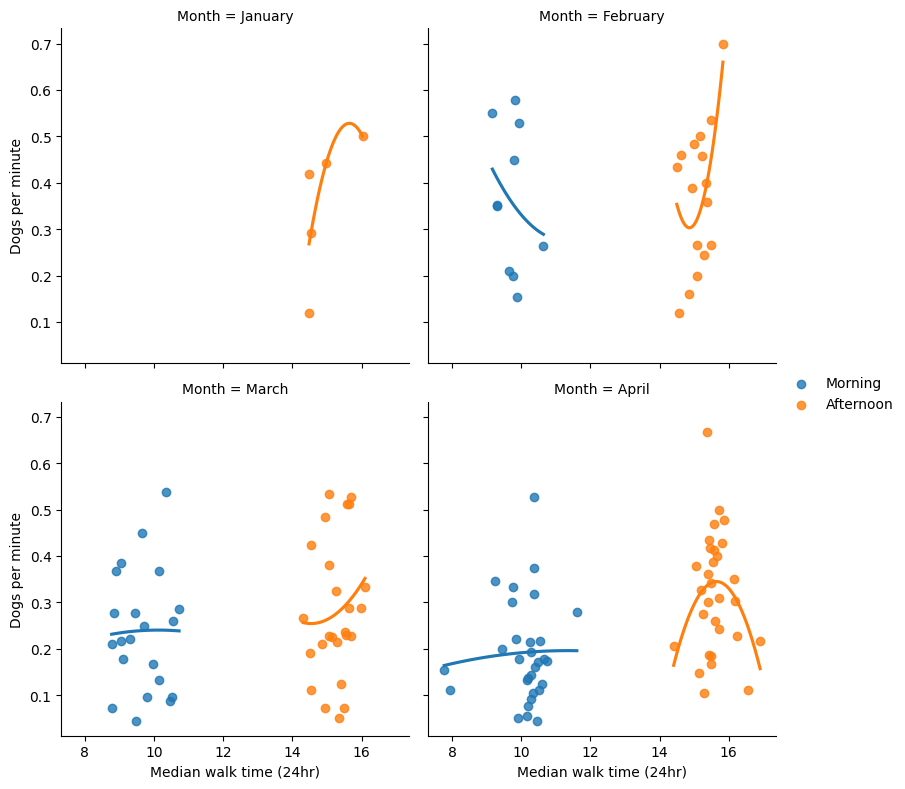

In [84]:
#And by month for seasonal patterns
grid_by_month = sb.FacetGrid(df,col="Month",col_wrap=2,hue="Walk_Type",hue_order=["Morning","Afternoon"],height=4,sharex=True)
grid_by_month.map_dataframe(sb.regplot, order=2, x="Avg_Time_Hour", y='Dogs_Per_Min', ci=None)
grid_by_month.add_legend(title="")
grid_by_month.set_axis_labels(x_var="Median walk time (24hr)",y_var="Dogs per minute")

In [85]:
#Split the dataset by route and average across routes for weather and temparature comparisons  
df_morning = df[df["Route"]=="Morning"].copy()
df_short = df[df["Route"]=="Short"].copy()
df_neighbourhood = df[df["Route"]=="Neighbourhoods"].copy()

weathermap_m = (
    df_morning.pivot_table(index="Weather", columns=["Temperature"], values="Dogs_Per_Min", aggfunc='mean')
)
weathermap_s = (
    df_short.pivot_table(index="Weather", columns=["Temperature"], values="Dogs_Per_Min", aggfunc='mean')
)
weathermap_n = (
    df_neighbourhood.pivot_table(index="Weather", columns=["Temperature"], values="Dogs_Per_Min", aggfunc='mean')
)

weathermap = pd.concat([weathermap_m, weathermap_s, weathermap_n]).groupby(level=0).mean()
weathermap = weathermap.reindex(["Sunny","Cloudy","Rainy"]) #There are only 3 weathers

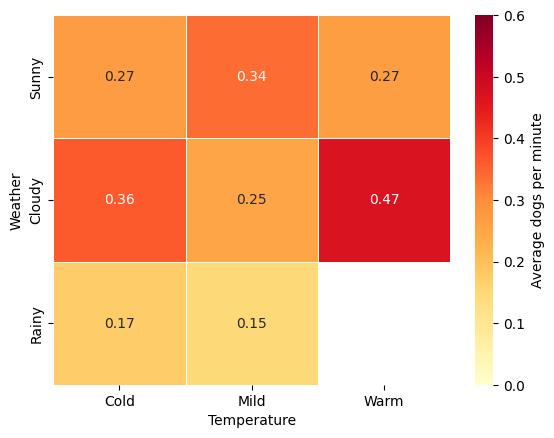

In [86]:

weather_heatmap = sb.heatmap(weathermap, vmin=0.0, vmax=0.6, annot=True, linewidths=0.5, cmap="YlOrRd",cbar_kws={'label': 'Average dogs per minute'})